<a href="https://colab.research.google.com/github/CarlosJB95/PathIA-MSI-colon/blob/main/notebooks/Notebook_03_Visualizaciones.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 3 — Visualizaciones del dataset

**Proyecto:** pathia-msi-colon  ·  **Autor:** Carlos  ·  **Fecha:** 11-sep-2026

**Objetivo:** presentar el análisis exploratorio (EDA) de las características de la cohorte mediante figuras a **calidad de publicación**, con estilo unificado y reproducible (cierre de la Semana 3 — visualización).

> ⚠️ **Alcance:** investigación y educación — evaluación de *factibilidad* metodológica, **no** herramienta diagnóstica ni de decisión clínica.

> 🧪 **Nota de datos:** las figuras usan un **manifest simulado** para ensayar la técnica de visualización. Para el análisis definitivo se sustituirá la celda de *Carga de datos* por la lectura de `manifest_slide.csv` real; el código de graficado **no cambia**.

---

## 0. Imports, semilla y estilo global

In [1]:
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Semilla global -> reproducibilidad
random.seed(42)
np.random.seed(42)

# Carpeta de salidas
Path('results').mkdir(exist_ok=True)

In [2]:
def aplicar_estilo():
    """Fija el estilo visual estándar del proyecto pathia-msi-colon.

    Centraliza la configuración de matplotlib (rcParams) para que TODAS las
    figuras del notebook compartan tamaño, tipografia, rejilla y resolución.
    Llamar una sola vez, tras los imports.
    """
    plt.rcParams.update({
        'figure.dpi': 110,      # nitidez en pantalla
        'savefig.dpi': 300,     # nitidez al guardar (publicacion)
        'font.size': 12,
        'axes.titlesize': 14,
        'axes.labelsize': 12,
        'axes.grid': True,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'figure.figsize': (8, 5),
    })

aplicar_estilo()

## 1. Carga de datos

Manifest **simulado** de la cohorte (300 laminillas, ~120 pacientes). El conteo de laminillas por paciente se calcula **por paciente** (no por parche), coherente con la regla de *splits por paciente*.

In [3]:
# --- Manifest SIMULADO (ensayo) ---
# Para datos reales, sustituir por:  df = pd.read_csv('manifest_slide.csv')
rng = np.random.default_rng(42)

n_laminillas = 300
df = pd.DataFrame({
    'slide_id':   [f's{i:04d}' for i in range(n_laminillas)],
    'patient_id': rng.integers(1, 120, n_laminillas),
    # cola derecha realista (muchas laminillas medianas, pocas enormes)
    'n_parches':  rng.lognormal(mean=5.0, sigma=0.5, size=n_laminillas).astype(int) + 20,
    # bimodal a proposito: 0.25 um/px (40x) vs 0.50 um/px (20x)
    'mpp':        rng.choice([0.25, 0.50], n_laminillas, p=[0.6, 0.4]),
})

# conteo POR PACIENTE
laminillas_por_paciente = df.groupby('patient_id').size()

print('Columnas:', list(df.columns))
print('Laminillas:', len(df), '| Pacientes unicos:', df['patient_id'].nunique())
df.head()

Columnas: ['slide_id', 'patient_id', 'n_parches', 'mpp']
Laminillas: 300 | Pacientes unicos: 107


,slide_id,patient_id,n_parches,mpp
0,s0000,11,272,0.50
1,s0001,93,180,0.25
2,s0002,78,157,0.25
3,s0003,53,108,0.25
4,s0004,52,84,0.25


## 2. Distribuciónes de dominio

Cada figura describe una caracteristica de la cohorte y **justifica una decision metodologica**:
parches/laminilla (control de muestreo), laminillas/paciente (por que el split es por paciente),
MPP (sesgo de escaner a controlar).

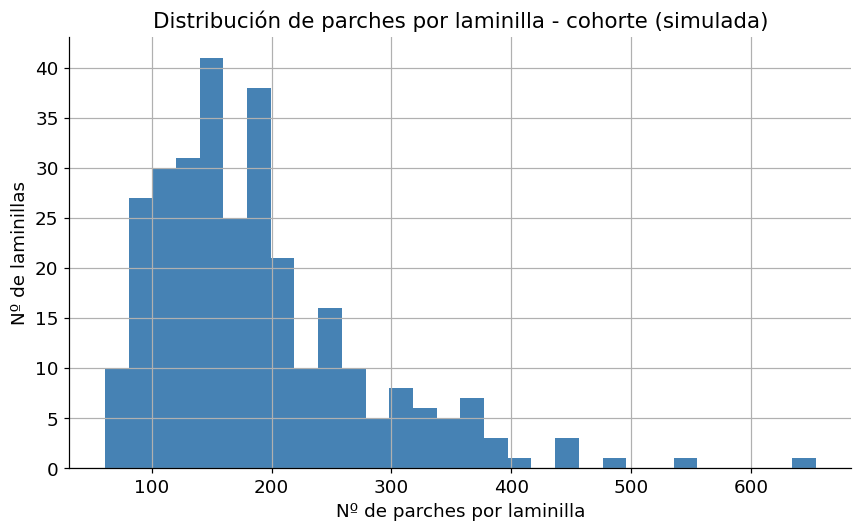

In [4]:
# Figura 1 - parches por laminilla
fig, ax = plt.subplots()
ax.hist(df['n_parches'], bins=30, color='steelblue')
ax.set_title('Distribución de parches por laminilla - cohorte (simulada)')
ax.set_xlabel('Nº de parches por laminilla')
ax.set_ylabel('Nº de laminillas')
fig.tight_layout()
fig.savefig('results/fig_parches_por_laminilla_v2.png', dpi=300, bbox_inches='tight')
plt.show()

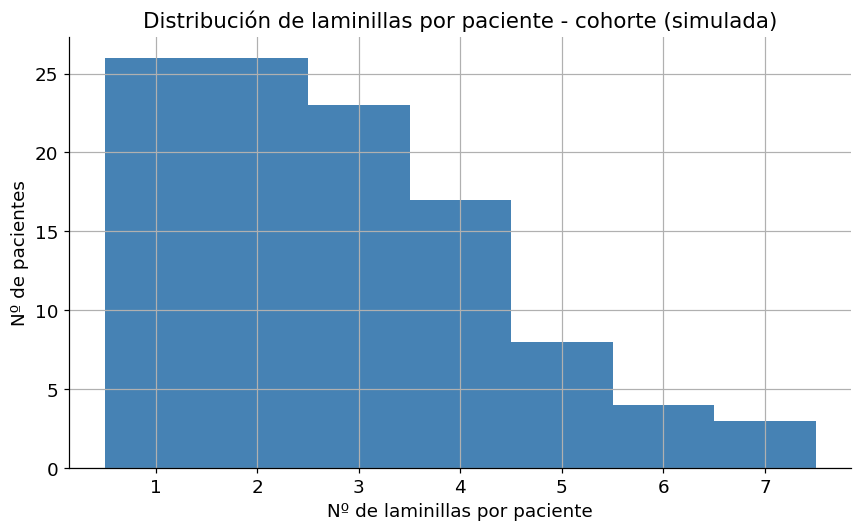

In [5]:
# Figura 2 - laminillas por paciente (distribucion)
fig, ax = plt.subplots()
ax.hist(laminillas_por_paciente,
        bins=range(1, laminillas_por_paciente.max() + 2),
        color='steelblue', align='left')
ax.set_title('Distribución de laminillas por paciente - cohorte (simulada)')
ax.set_xlabel('Nº de laminillas por paciente')
ax.set_ylabel('Nº de pacientes')
fig.tight_layout()
fig.savefig('results/fig_laminillas_por_paciente_v2.png', dpi=300, bbox_inches='tight')
plt.show()

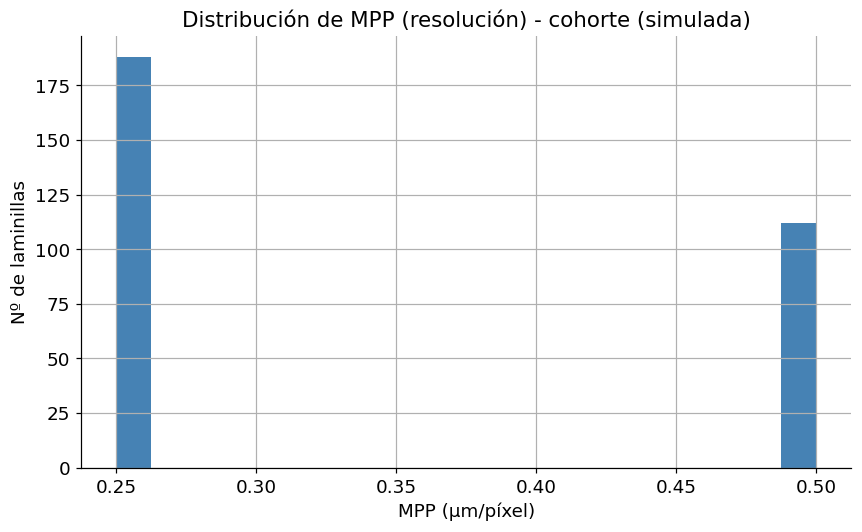

In [6]:
# Figura 3 - MPP (resolución)
fig, ax = plt.subplots()
ax.hist(df['mpp'], bins=20, color='steelblue')
ax.set_title('Distribución de MPP (resolución) - cohorte (simulada)')
ax.set_xlabel('MPP (µm/píxel)')
ax.set_ylabel('Nº de laminillas')
fig.tight_layout()
fig.savefig('results/fig_mpp_v2.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. Panel resumen del EDA

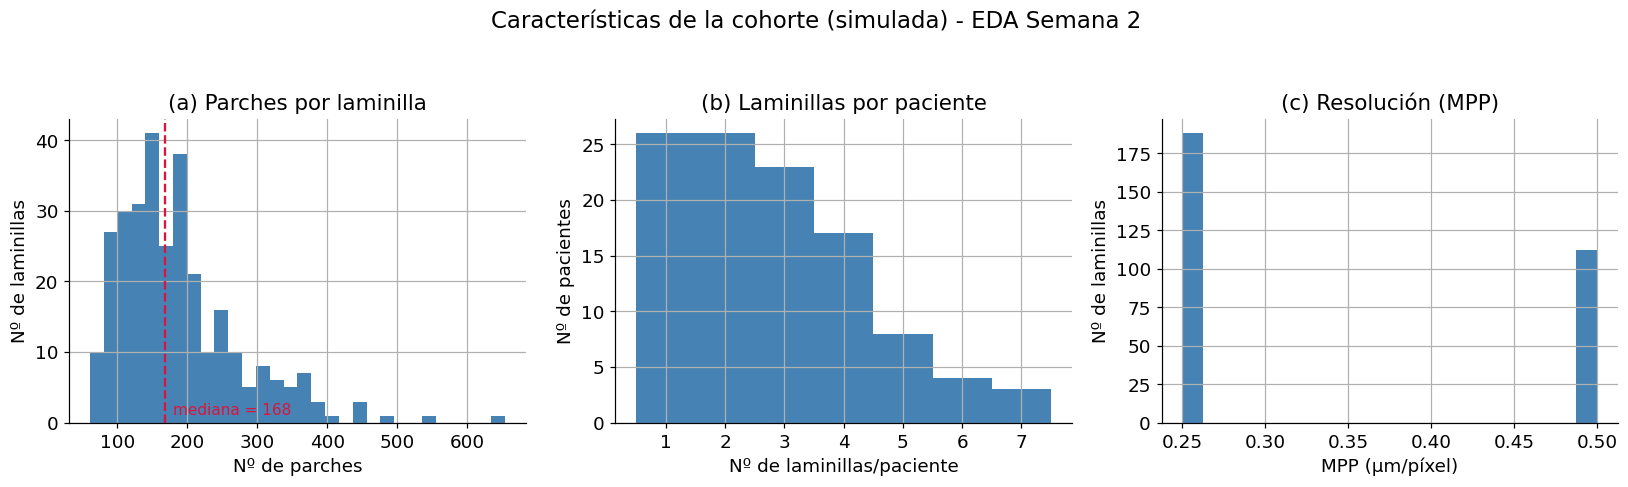

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# (a) parches por laminilla + mediana anotada
axes[0].hist(df['n_parches'], bins=30, color='steelblue')
axes[0].set_title('Parches por laminilla')
axes[0].set_xlabel('Nº de parches')
axes[0].set_ylabel('Nº de laminillas')
med = df['n_parches'].median()
axes[0].axvline(med, color='crimson', linestyle='--', linewidth=1.5)
axes[0].annotate(f'mediana = {med:.0f}', xy=(med, 0), xytext=(5, 5),
                 textcoords='offset points', color='crimson', fontsize=10)

# (b) laminillas por paciente
axes[1].hist(laminillas_por_paciente,
             bins=range(1, laminillas_por_paciente.max() + 2),
             color='steelblue', align='left')
axes[1].set_title('Laminillas por paciente')
axes[1].set_xlabel('Nº de laminillas/paciente')
axes[1].set_ylabel('Nº de pacientes')

# (c) MPP
axes[2].hist(df['mpp'], bins=20, color='steelblue')
axes[2].set_title('Resolución (MPP)')
axes[2].set_xlabel('MPP (µm/píxel)')
axes[2].set_ylabel('Nº de laminillas')

# etiquetas de panel (a)/(b)/(c) - dentro del panel, sobre su propio axes 1x3
for a, letra in zip(axes, ['a', 'b', 'c']):
    a.set_title(f'({letra}) ' + a.get_title())

fig.suptitle('Características de la cohorte (simulada) - EDA Semana 2', fontsize=15)
fig.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig('results/fig_eda_semana2_v2.png', dpi=300, bbox_inches='tight')
plt.show()

## Como reproducir

1. Entorno: `pip install -r requirements.txt` (numpy, pandas, matplotlib, seaborn).
2. Ejecutar **Kernel -> Restart & Run All**. La semilla global (42) garantiza resultados identicos.
3. Salidas: se escriben en `results/*.png` a **300 dpi**.
4. Datos reales: sustituir la celda *Carga de datos* por `df = pd.read_csv('manifest_slide.csv')` (columnas: slide_id, patient_id, n_parches, mpp).

---
# Anexos

## Anexo A - Ejercicio de practica (Titanic)

> No forma parte del analisis de la cohorte. Es practica de tecnica (`barplot` sobre una variable binaria: la media = proporcion).

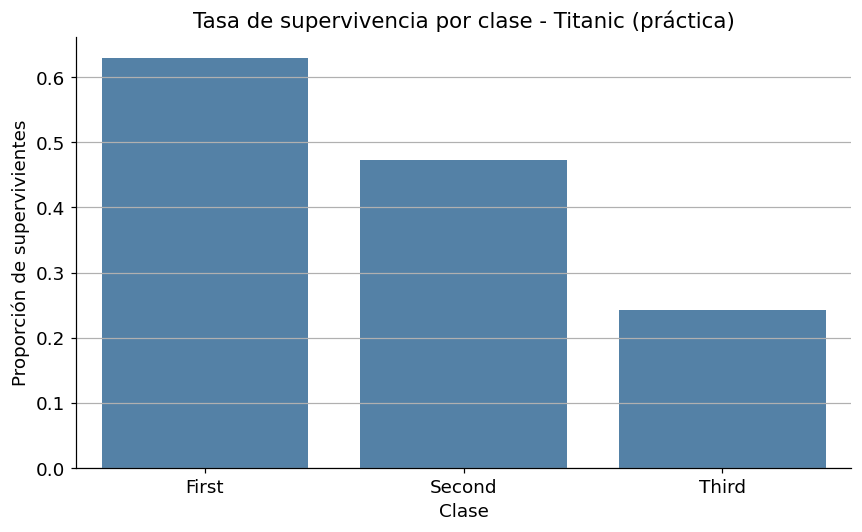

In [8]:
titanic = sns.load_dataset('titanic')

fig, ax = plt.subplots()
sns.barplot(data=titanic, x='class', y='survived', ax=ax,
            color='steelblue', errorbar=None)
ax.set_title('Tasa de supervivencia por clase - Titanic (práctica)')
ax.set_xlabel('Clase')
ax.set_ylabel('Proporción de supervivientes')
fig.tight_layout()
plt.show()

## Anexo B - Checklist de figura publicable

**Legibilidad**
- [ ] Ejes rotulados CON unidades
- [ ] Titulo por subplot (+ supertitulo si es panel)
- [ ] Tipografia legible; paneles sin encimarse (tight_layout)
- [ ] Leyenda solo si aporta

**Eleccion correcta**
- [ ] Tipo de grafico <-> pregunta (categorica->barras; distribucion->hist/box; relacion->dispersion)
- [ ] Bins sensatos (divisor del rango; no fabrican picos)
- [ ] Color con intencion (secuencial/categorica/divergente; colorblind-safe; nunca jet)

**Honestidad**
- [ ] Barras desde 0; ejes truncados SIEMPRE rotulados
- [ ] Sin chartjunk (3D, sombras, color decorativo)
- [ ] La figura no exagera una señal que no esta

**Consistencia y reproducibilidad**
- [ ] Estilo uniforme (aplicar_estilo / rcParams)
- [ ] Formato segun destino (300 dpi impreso / 150 pantalla)
- [ ] Semilla fija + guardada con nombre versionado + regenerable con Run all

In [9]:
from google.colab import files #opcional, colab-only
for f in ['fig_parches_por_laminilla_v2.png','fig_laminillas_por_paciente_v2.png',
          'fig_mpp_v2.png','fig_eda_semana2_v2.png']:
    files.download(f'results/{f}')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>